In [46]:
from tqdm import tqdm

import torch
from torch import nn
import torch.nn.functional as F
from torch.optim import Adam, SGD
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, Subset

from torchvision.datasets import CIFAR10
from torchvision import transforms

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Чтение и подготовка данных

Для начала обозначим преобразования для данных. Нам нужно превратить картинки в тензоры, для этого есть ToTensor(), а также нормализовать данные от 0 до 1 (значения от 0 до 255 имеют большой скейл и нейронки хуже будут с ними работать)

In [47]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261))
])

Теперь создадим готовый датасет из PyTorch и загрузчик данных для создания батчей

In [48]:
train_dataset = CIFAR10(root='cifar10', train=True, download=True, transform=transform)

In [49]:
print(train_dataset[0][0].shape)

torch.Size([3, 32, 32])


Давайте посмотрим, что возвращает датасет и даталоадер

In [50]:
train_loader = DataLoader(dataset=train_dataset, batch_size=8, shuffle=True)

Посмотрим как выглядит семпл

In [51]:
batch = next(iter(train_loader))
batch[0].shape

torch.Size([8, 3, 32, 32])

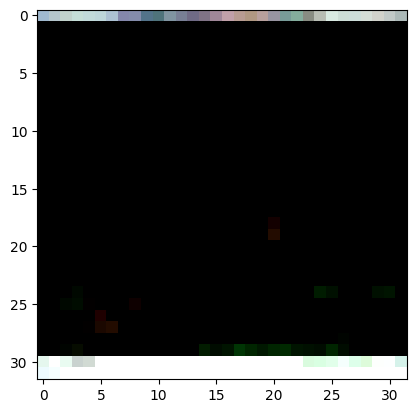

In [52]:
sample_img = batch[0].numpy()[1].transpose(1, 2, 0)

plt.imshow(sample_img)

# Простая CNN

Давайте сделаем простую CNN. Сделаем ее с 3 свертками и пулингом

In [53]:
class BasicCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(1024, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        x = x.view(-1, 64 * 4 * 4)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

Посмотрим, что она выдаст

In [54]:
cnn = BasicCNN()

out = cnn(batch[0])
print(out.shape)

torch.Size([8, 10])


# Напишем код для тренировки

Тренировка и тестирование будет реализованно в классе Trainer

Обозначим конфиг, где будут параметры для тренировки

In [55]:
config = {
    'num_epochs': 10,
    'lr': 0.01,
    'batch_size': 128,
    'test_size': 0.2
}

In [67]:
class Trainer:
    def __init__(self, config, model="BasicCNN", transform=None):
        super().__init__()
        self.config = config
        self.transform = transform

        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        if model == "BasicCNN":
          self.model = BasicCNN().to(self.device)
        elif model == "ResNet18":
          self.model = ResNet18().to(self.device)

        self.optimizer = Adam(self.model.parameters(), lr=self.config['lr'])
        self.scheduler = StepLR(self.optimizer, step_size=5, gamma=0.1)
        self.loss_function = nn.CrossEntropyLoss()

        self.train_accuracies = []
        self.val_accuracies = []
        self.test_accuracies = []
        self.train_losses = []
        self.val_losses = []

        self.setup_dataloaders()

    def setup_dataloaders(self):
        train_dataset_full = CIFAR10(root='cifar10', train=True, download=True, transform=self.transform)
        test_dataset = CIFAR10(root='cifar10', train=False, download=True, transform=self.transform)

        train_indices, val_indices = train_test_split(list(range(len(train_dataset_full))), test_size=self.config['test_size'], random_state=42, shuffle=True)
        train_dataset = Subset(train_dataset_full, train_indices)
        val_dataset = Subset(train_dataset_full, val_indices)

        self.train_loader = DataLoader(dataset=train_dataset, batch_size=self.config['batch_size'], shuffle=True)
        self.val_loader = DataLoader(dataset=val_dataset, batch_size=self.config['batch_size'], shuffle=False)
        self.test_loader = DataLoader(dataset=test_dataset, batch_size=self.config['batch_size'], shuffle=False)

    def run(self):
        for epoch in range(self.config['num_epochs']):
            train_loss, train_acc = self.train_step()
            val_loss, val_acc = self.val_step()

            print(f'Epoch {epoch + 1} / {self.config['num_epochs']}', train_loss, val_loss, val_acc)
            self.train_accuracies.append(train_acc)
            self.val_accuracies.append(val_acc)
            self.train_losses.append(train_loss)
            self.val_losses.append(val_loss)

        test_loss, test_acc = self.test_step()
        print(f'Test loss {test_loss}, test acc {test_acc}')
        self.test_accuracies.append(test_acc)

        self.plot_accuracies()
        self.plot_losses()

    def train_step(self):
        self.model.train()

        total_loss = 0.0
        correct = 0
        total_samples = 0

        for images, labels in tqdm(self.train_loader):
            images, labels = images.to(self.device), labels.to(self.device)

            self.optimizer.zero_grad()

            outputs = self.model(images)
            loss = self.loss_function(outputs, labels)

            loss.backward()

            self.optimizer.step()

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

        self.scheduler.step()

        total_loss = total_loss / len(self.train_loader)
        train_acc = correct / total_samples * 100

        return total_loss, train_acc

    def val_step(self):
        self.model.eval()

        total_loss = 0.0
        correct = 0
        total_samples = 0

        for images, labels in tqdm(self.val_loader):
            images, labels = images.to(self.device), labels.to(self.device)

            with torch.no_grad():
                outputs = self.model(images)
            loss = self.loss_function(outputs, labels)

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

        total_loss = total_loss / len(self.val_loader)
        val_acc = correct / total_samples * 100

        return total_loss, val_acc

    def test_step(self):
        self.model.eval()

        total_loss = 0.0
        correct = 0
        total_samples = 0

        for images, labels in tqdm(self.test_loader):
            images, labels = images.to(self.device), labels.to(self.device)

            with torch.no_grad():
                outputs = self.model(images)
            loss = self.loss_function(outputs, labels)

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

        total_loss = total_loss / len(self.test_loader)
        test_acc = correct / total_samples * 100

        return total_loss, test_acc

    def plot_accuracies(self):
        epochs = range(1, self.config['num_epochs'] + 1)
        plt.figure(figsize=(10, 6))
        plt.plot(epochs, self.train_accuracies, label='Training Accuracy')
        plt.plot(epochs, self.val_accuracies, label='Validation Accuracy')

        if self.test_accuracies:
            plt.axhline(y=self.test_accuracies[0], color='r', linestyle='--', label='Test Accuracy')

        plt.xlabel('Epoch')
        plt.ylabel('Accuracy (%)')
        plt.title('Training, Validation, and Test Accuracy over Epochs')
        plt.legend()
        plt.grid(True)
        plt.show()

    def plot_losses(self):
        epochs = range(1, self.config['num_epochs'] + 1)
        plt.figure(figsize=(10, 6))
        plt.plot(epochs, self.train_losses, label='Training Loss')
        plt.plot(epochs, self.val_losses, label='Validation Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Training and Validation Loss over Epochs')
        plt.legend()
        plt.grid(True)
        plt.show()


# ResNet-18

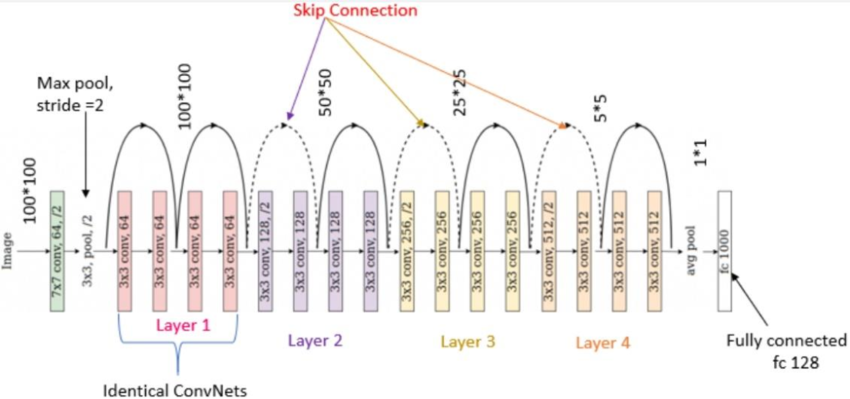

In [57]:
class ResNetBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.downsample = downsample

    def forward(self, x):
        identity = x

        if self.downsample is not None:
            identity = self.downsample(identity)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out += identity
        out = self.relu(out)

        return out

class ResNet18(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.in_channels = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.max_poool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self.make_layer(64, 2)
        self.layer2 = self.make_layer(128, 2, stride=2)
        self.layer3 = self.make_layer(256, 2, stride=2)
        self.layer4 = self.make_layer(512, 2, stride=2)

        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def make_layer(self, out_channels, blocks, stride=1):
        downsample = None
        if stride != 1 or out_channels != self.in_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels, kernel_size=1, stride=stride),
                nn.BatchNorm2d(out_channels)
            )
        layers = []
        layers.append(ResNetBlock(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels
        for _ in range(1, blocks):
            layers.append(ResNetBlock(self.in_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.max_poool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avg_pool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

$H_{out}=\frac{H_{in}+2P-D(K-1)-1}{S}+1$ \\
$W_{out}=\frac{W_{in}+2P-D(K-1)-1}{S}+1$

In [58]:
def print_confusion_matrix(trainer_instance):
    trainer_instance.model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in trainer_instance.test_loader:
            images, labels = images.to(trainer_instance.device), labels.to(trainer_instance.device)
            outputs = trainer_instance.model(images)
            _, predicted = torch.max(outputs.data, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

In [68]:
trainer_BasicCNN = Trainer(config, model="BasicCNN", transform=transform)

100%|██████████| 79/79 [00:03<00:00, 20.51it/s]


Epoch 1 / 10 1.5934299645713343 1.3978948215895062 49.51


100%|██████████| 79/79 [00:03<00:00, 22.16it/s]


Epoch 2 / 10 1.336673778466904 1.256915499892416 54.65


100%|██████████| 79/79 [00:02<00:00, 30.50it/s]


...

Epoch 9 / 10 0.8876495416552875 1.0964685188064092 62.28


100%|██████████| 79/79 [00:03<00:00, 26.02it/s]


Epoch 10 / 10 0.8716991509492404 1.1080034933512724 62.43


100%|██████████| 79/79 [00:02<00:00, 30.84it/s]


Test loss 1.133171662499633, test acc 61.39


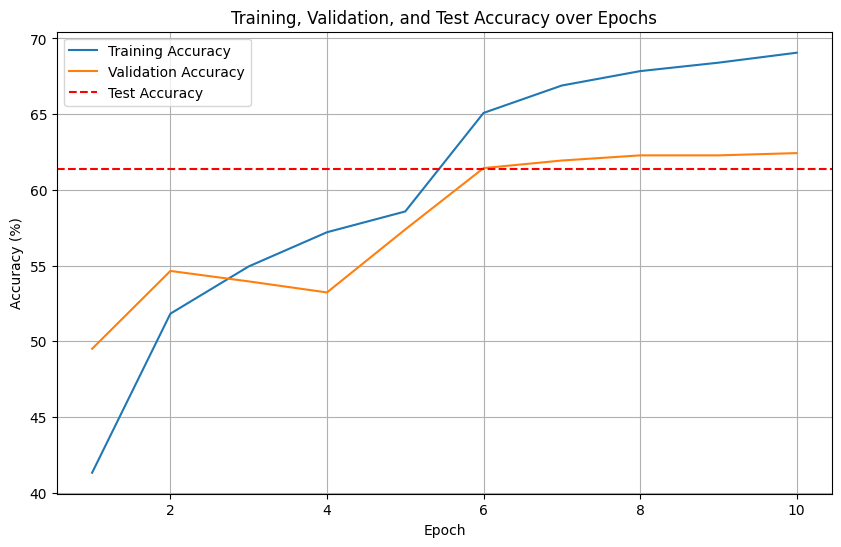

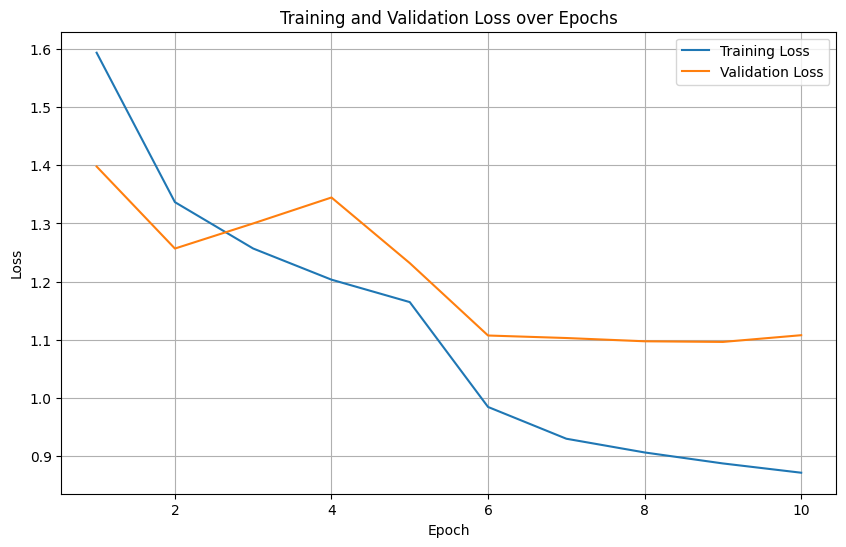

In [69]:
trainer_BasicCNN.run()

100%|██████████| 79/79 [00:03<00:00, 25.61it/s]


Epoch 1 / 10 1.8312937173599633 1.5951051712036133 43.63


100%|██████████| 79/79 [00:03<00:00, 24.08it/s]


Epoch 2 / 10 1.3453421021421876 1.2369309754311284 55.720000000000006


100%|██████████| 79/79 [00:03<00:00, 20.22it/s]


...

Epoch 9 / 10 0.28575547796468764 0.8307368114024778 76.12


100%|██████████| 79/79 [00:02<00:00, 26.51it/s]


Epoch 10 / 10 0.21450063407706757 0.9346139506448673 75.69


100%|██████████| 79/79 [00:03<00:00, 23.31it/s]


Test loss 1.005113094667845, test acc 74.28


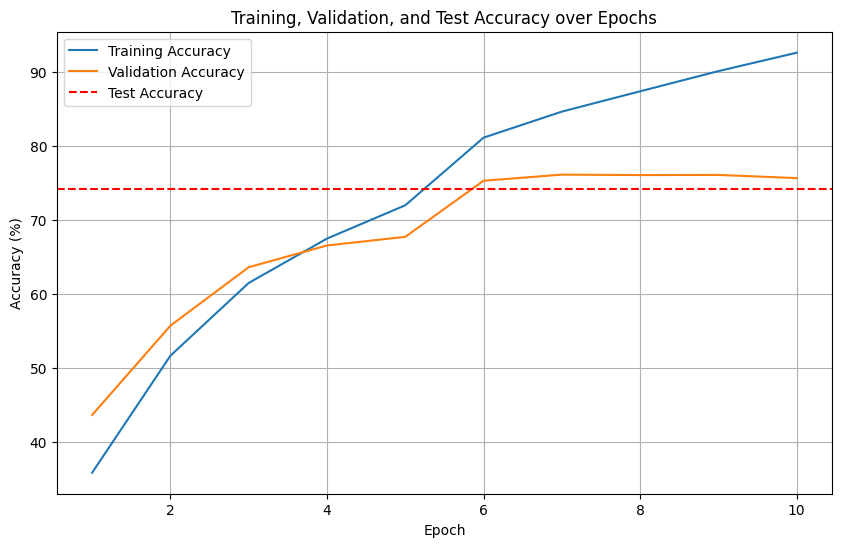

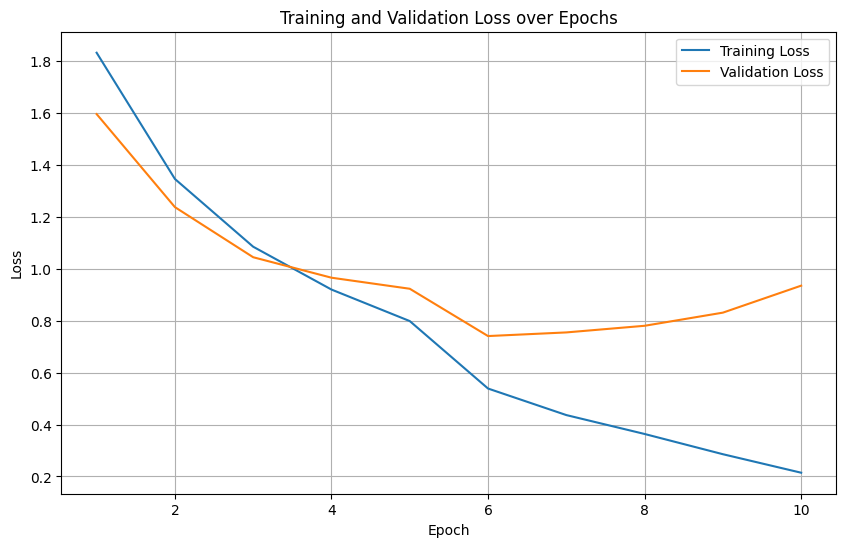

In [70]:
trainer_ResNet18 = Trainer(config, model="ResNet18", transform=transform)
trainer_ResNet18.run()


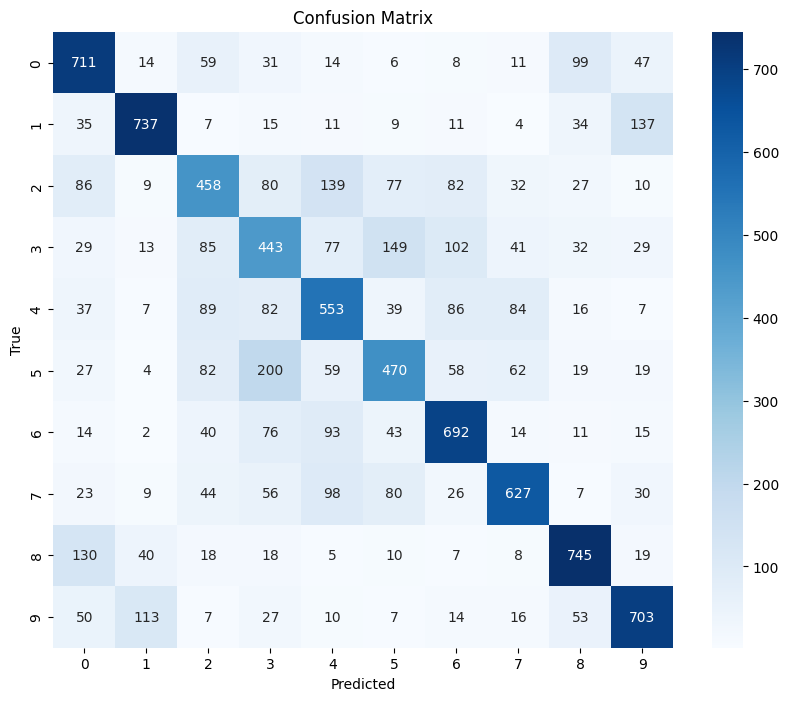

In [71]:
print_confusion_matrix(trainer_BasicCNN)

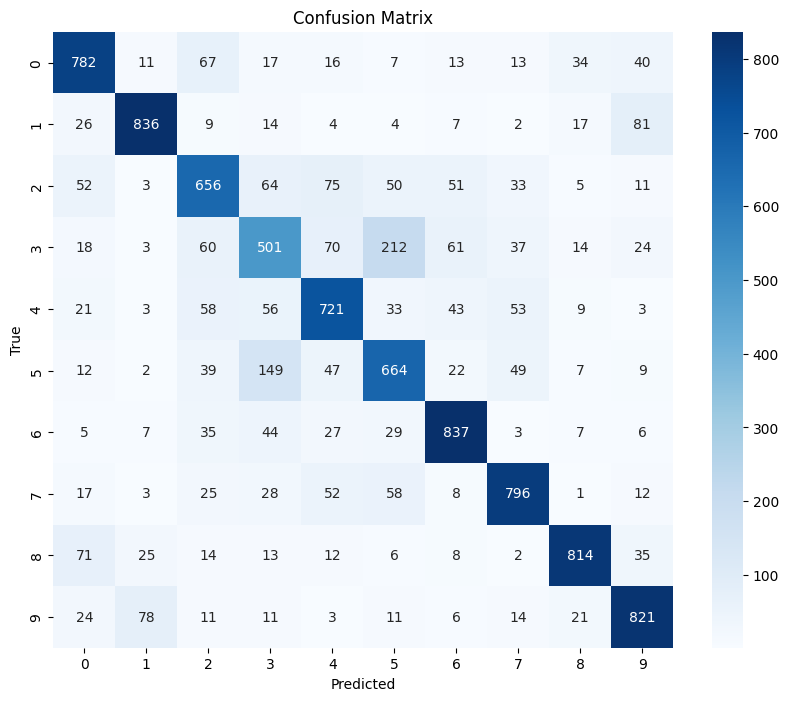

In [72]:
print_confusion_matrix(trainer_ResNet18)

In [73]:
print(train_dataset.classes[3], train_dataset.classes[5])

cat dog


Ну короче тут видно, что качество хорошо так возросло, сетка стала меньше путаться, хотя котов и собак всё равно часто путает

бтв мне было лень объединять графики лоссов и точности у моделей, в целом тут и так всё видно
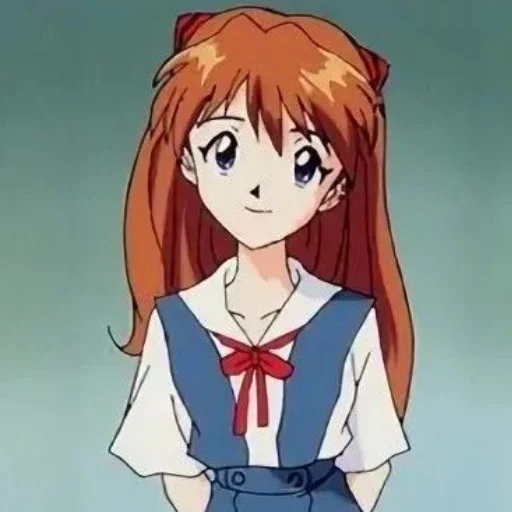